In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [8]:
df = pd.read_csv('data/raw/stock_prices.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [9]:
print(df.info())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB
None
Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')


In [10]:
print(df['Name'].unique())

['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG' 'AIV' 'AIZ' 'AJG'
 'AKAM' 'ALB' 'ALGN' 'ALK' 'ALLE' 'ALL' 'ALXN' 'AMAT' 'AMD' 'AME' 'AMGN'
 'AMG' 'AMP' 'AMT' 'AMZN' 'ANDV' 'ANSS' 'ANTM' 'AON' 'AOS' 'APA' 'APC'
 'APD' 'APH' 'APTV' 'ARE' 'ARNC' 'ATVI' 'AVB' 'AVGO' 'AVY' 'AWK' 'AXP'
 'AYI' 'AZO' 'A' 'BAC' 'BAX' 'BA' 'BBT' 'BBY' 'BDX' 'BEN' 'BF.B' 'BHF'
 'BHGE' 'BIIB' 'BK' 'BLK' 'BLL' 'BMY' 'BRK.B' 'BSX' 'BWA' 'BXP' 'CAG'
 'CAH' 'CAT' 'CA' 'CBG' 'CBOE' 'CBS' 'CB' 'CCI' 'CCL' 'CDNS' 'CELG' 'CERN'
 'CFG' 'CF' 'CHD' 'CHK' 'CHRW' 'CHTR' 'CINF' 'CI' 'CLX' 'CL' 'CMA' 'CMCSA'
 'CME' 'CMG' 'CMI' 'CMS' 'CNC' 'CNP' 'COF' 'COG' 'COL' 'COO' 'COP' 'COST'
 'COTY' 'CPB' 'CRM' 'CSCO' 'CSRA' 'CSX' 'CTAS' 'CTL' 'CTSH' 'CTXS' 'CVS'
 'CVX' 'CXO' 'C' 'DAL' 'DE' 'DFS' 'DGX' 'DG' 'DHI' 'DHR' 'DISCA' 'DISCK'
 'DISH' 'DIS' 'DLR' 'DLTR' 'DOV' 'DPS' 'DRE' 'DRI' 'DTE' 'DUK' 'DVA' 'DVN'
 'DWDP' 'DXC' 'D' 'EA' 'EBAY' 'ECL' 'ED' 'EFX' 'EIX' 'E

In [11]:
df = df[df['Name'] == 'AAPL']

In [13]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

In [14]:
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

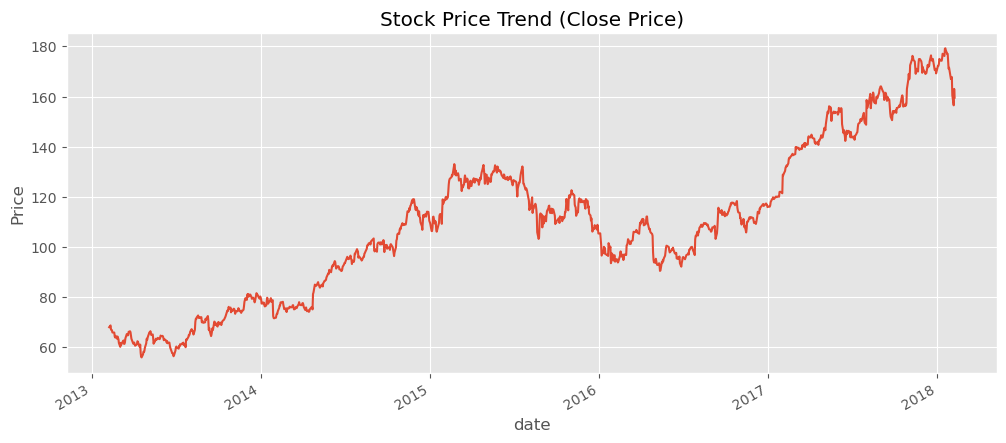

Insight:
- Stock price shows overall trend over time.
- There are fluctuations due to market changes.


In [16]:
plt.figure(figsize=(12,5))
df['close'].plot()

plt.title("Stock Price Trend (Close Price)")
plt.xlabel("date")
plt.ylabel("Price")

plt.show()

print("Insight:")
print("- Stock price shows overall trend over time.")
print("- There are fluctuations due to market changes.")

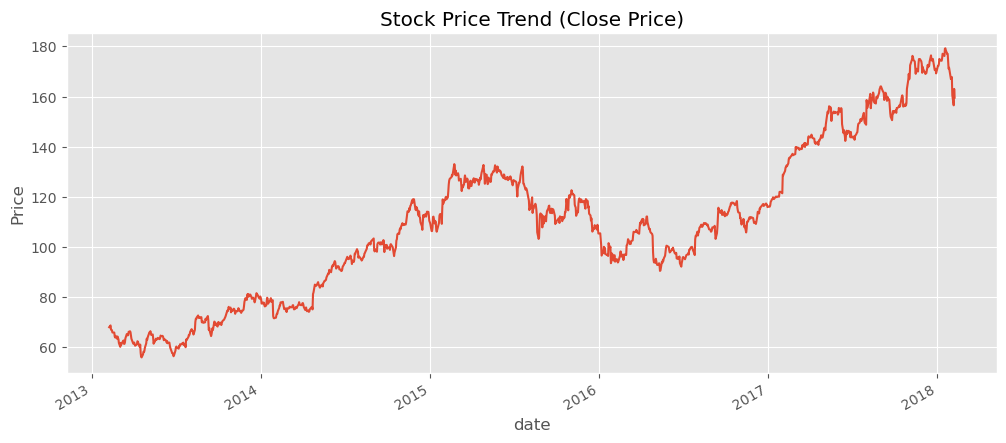

Insight:
- Stock price shows overall trend over time.
- There are fluctuations due to market changes.


In [17]:
plt.figure(figsize=(12,5))
df['close'].plot()

plt.title("Stock Price Trend (Close Price)")
plt.xlabel("date")
plt.ylabel("Price")

plt.show()

print("Insight:")
print("- Stock price shows overall trend over time.")
print("- There are fluctuations due to market changes.")

<Figure size 1200x500 with 0 Axes>

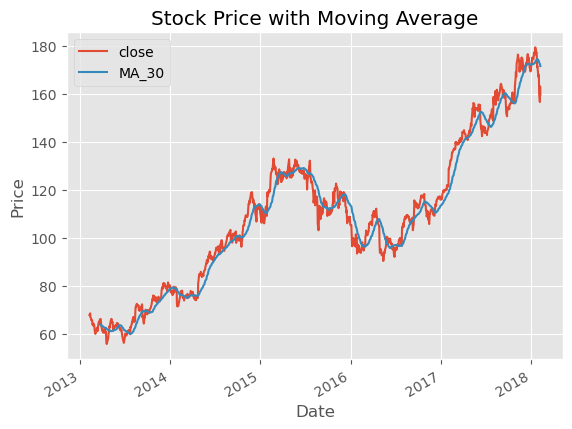

Insight:
- Moving average smooths fluctuations.
- Shows long-term trend clearly.


In [20]:
df['MA_30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
df[['close', 'MA_30']].plot()

plt.title("Stock Price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

print("Insight:")
print("- Moving average smooths fluctuations.")
print("- Shows long-term trend clearly.")

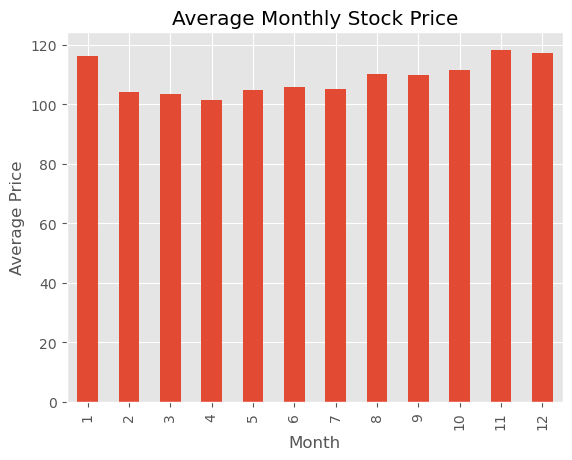

Insight:
- Some months show higher average prices.
- Indicates seasonal patterns in stock movement.


In [22]:
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['close'].mean()

monthly_avg.plot(kind='bar')

plt.title("Average Monthly Stock Price")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

print("Insight:")
print("- Some months show higher average prices.")
print("- Indicates seasonal patterns in stock movement.")

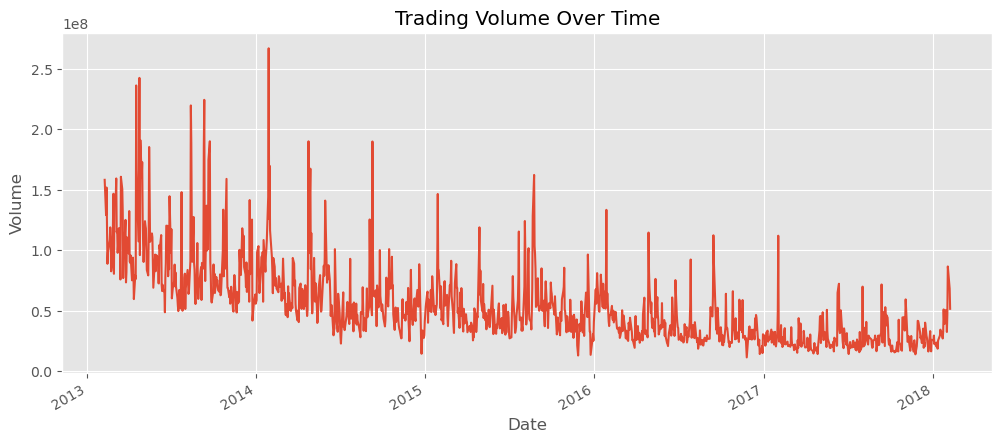

Insight:
- Volume spikes indicate high trading activity.
- Can relate to major market events.


In [24]:
plt.figure(figsize=(12,5))
df['volume'].plot()

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

print("Insight:")
print("- Volume spikes indicate high trading activity.")
print("- Can relate to major market events.")

In [26]:
# Final Insights:
# - Stock shows overall increasing trend
# - Moving average smooths fluctuations
# - Seasonal variation observed in some months
# - Volume spikes indicate major events